In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

In [46]:
# Load all trips and get SOC change statistics
trip_files = sorted(glob('BMW_i3_Dataset/Trip*.csv'))
trip_info = []

for trip_file in trip_files:
    trip = pd.read_csv(trip_file, sep=';', encoding='latin-1')
    trip_name = trip_file.split('\\')[-1].replace('.csv', '')
    
    soc_start = trip['SoC [%]'].iloc[0]
    soc_end = trip['SoC [%]'].iloc[-1]
    soc_change = soc_start - soc_end
    duration_min = trip['Time [s]'].max() / 60
    
    trip_info.append({
        'Trip': trip_name,
        'Category': 'Summer (A)' if 'TripA' in trip_name else 'Winter (B)',
        'SOC_Start': soc_start,
        'SOC_End': soc_end,
        'SOC_Change': soc_change,
        'Duration_min': duration_min
    })

trips_summary = pd.DataFrame(trip_info)

# Find max SOC change for summer and winter
summer_trips = trips_summary[trips_summary['Category'] == 'Summer (A)']
winter_trips = trips_summary[trips_summary['Category'] == 'Winter (B)']

max_summer = summer_trips.loc[summer_trips['SOC_Change'].idxmax()]
max_winter = winter_trips.loc[winter_trips['SOC_Change'].idxmax()]

print(f"Total trips: {len(trips_summary)}")
print(f"Summer trips: {len(summer_trips)}, Winter trips: {len(winter_trips)}")
print(f"\nMax SOC Change (Summer): {max_summer['Trip']} - {max_summer['SOC_Change']:.1f}% over {max_summer['Duration_min']:.1f} min")
print(f"Max SOC Change (Winter): {max_winter['Trip']} - {max_winter['SOC_Change']:.1f}% over {max_winter['Duration_min']:.1f} min")

print(f"\nAll trips sorted by SOC change:")
print(trips_summary.sort_values('SOC_Change', ascending=False)[['Trip', 'Category', 'SOC_Change', 'Duration_min']])

Total trips: 70
Summer trips: 32, Winter trips: 38

Max SOC Change (Summer): TripA07 - 29.2% over 34.9 min
Max SOC Change (Winter): TripB14 - 85.5% over 63.7 min

All trips sorted by SOC change:
       Trip    Category  SOC_Change  Duration_min
45  TripB14  Winter (B)        85.5     63.698333
6   TripA07  Summer (A)        29.2     34.886667
32  TripB01  Winter (B)        28.7     54.195000
31  TripA32  Summer (A)        27.0     27.868333
5   TripA06  Summer (A)        21.7     52.740000
..      ...         ...         ...           ...
63  TripB32  Winter (B)         NaN     13.261667
65  TripB34  Winter (B)         NaN     12.228333
66  TripB35  Winter (B)         NaN     22.708333
67  TripB36  Winter (B)         NaN     47.536667
68  TripB37  Winter (B)         NaN     23.620000

[70 rows x 4 columns]


In [47]:
summer_file = f"BMW_i3_Dataset/{max_summer['Trip']}.csv"
winter_file = f"BMW_i3_Dataset/{max_winter['Trip']}.csv"

df_summer = pd.read_csv(summer_file, sep=';', encoding='latin-1')
df_winter = pd.read_csv(winter_file, sep=';', encoding='latin-1')

print(f"Summer Trip: {max_summer['Trip']}")
print(f"  Samples: {len(df_summer):,}")
print(f"  Duration: {df_summer['Time [s]'].max()/60:.1f} min")
print(f"  SOC: {df_summer['SoC [%]'].iloc[0]:.1f}% → {df_summer['SoC [%]'].iloc[-1]:.1f}% (Δ{max_summer['SOC_Change']:.1f}%)")

print(f"\nWinter Trip: {max_winter['Trip']}")
print(f"  Samples: {len(df_winter):,}")
print(f"  Duration: {df_winter['Time [s]'].max()/60:.1f} min")
print(f"  SOC: {df_winter['SoC [%]'].iloc[0]:.1f}% → {df_winter['SoC [%]'].iloc[-1]:.1f}% (Δ{max_winter['SOC_Change']:.1f}%)")

Summer Trip: TripA07
  Samples: 20,933
  Duration: 34.9 min
  SOC: 63.4% → 34.2% (Δ29.2%)

Winter Trip: TripB14
  Samples: 38,220
  Duration: 63.7 min
  SOC: 85.5% → 0.0% (Δ85.5%)


In [48]:
print(f"Summer Trip ({max_summer['Trip']}) - First 10 rows:")
display(df_summer.head(10))

Summer Trip (TripA07) - First 10 rows:


,Time [s],Velocity [km/h],Elevation [m],Throttle [%],Motor Torque [Nm],Longitudinal Acceleration [m/s^2],Regenerative Braking Signal,Battery Voltage [V],Battery Current [A],Battery Temperature [°C],max. Battery Temperature [°C],SoC [%],displayed SoC [%],min. SoC [%],max. SoC [%),Heating Power CAN [kW],Requested Heating Power [W],AirCon Power [kW],Heater Signal,Ambient Temperature [°C],Requested Coolant Temperature [°C],Heat Exchanger Temperature [°C],Cabin Temperature Sensor [°C]
0,0.0,2.22,487.0,25.18,25.00,0.54,0.0,379.90,-12.90,31.0,32.0,63.4,72.0,8,90,0.0,0,2.56,0,33.5,0,14.5,39.84
1,0.1,2.32,487.0,25.49,35.53,0.68,0.0,379.89,-13.00,31.0,32.0,63.4,72.0,8,90,0.0,0,2.56,0,33.5,0,14.5,39.84
2,0.2,2.53,487.0,25.03,48.03,0.92,0.0,379.79,-14.10,31.0,32.0,63.4,72.0,8,90,0.0,0,2.56,0,33.5,0,14.5,39.84
3,0.3,2.81,487.0,24.89,55.97,1.06,0.0,379.70,-15.14,31.0,32.0,63.4,72.0,8,90,0.0,0,2.56,0,33.5,0,14.5,39.84
4,0.4,3.12,487.0,24.08,56.09,1.10,0.0,379.70,-15.59,31.0,32.0,63.4,72.0,8,90,0.0,0,2.56,0,33.5,0,14.5,39.84
5,0.5,3.47,487.0,22.54,59.38,1.12,0.0,379.70,-16.00,31.0,32.0,63.4,72.0,8,90,0.0,0,2.56,0,33.5,0,14.5,39.84
6,0.6,3.80,487.0,20.03,59.00,1.09,0.0,379.70,-16.05,31.0,32.0,63.4,72.0,8,90,0.0,0,2.56,0,33.5,0,14.5,39.84
7,0.7,4.12,487.0,17.10,55.97,0.99,0.0,379.70,-16.00,31.0,32.0,63.4,72.0,8,90,0.0,0,2.56,0,33.5,0,14.5,39.84
8,0.8,4.38,487.0,15.27,47.75,0.84,0.0,379.75,-14.90,31.0,32.0,63.4,72.0,8,90,0.0,0,2.56,0,33.5,0,14.5,39.84
9,0.9,4.58,487.0,14.80,36.38,0.65,0.0,379.80,-13.81,31.0,32.0,63.4,72.0,8,90,0.0,0,2.56,0,33.5,0,14.5,39.84


In [49]:
soc_col = [col for col in df_summer.columns if 'SoC' in col and 'displayed' not in col][0]
voltage_col = [col for col in df_summer.columns if 'Battery Voltage' in col and 'min' not in col and 'max' not in col][0]
current_col = [col for col in df_summer.columns if 'Battery Current' in col and 'min' not in col and 'max' not in col][0]
temp_col = [col for col in df_summer.columns if 'Battery Temperature' in col and 'min' not in col and 'max' not in col][0]
velocity_col = [col for col in df_summer.columns if 'Velocity' in col and 'displayed' not in col and 'min' not in col and 'max' not in col][0]
elevation_col = [col for col in df_summer.columns if 'Elevation' in col][0]

print(f"\nSOC: {df_summer[soc_col].describe()}")
print(f"\nVoltage: {df_summer[voltage_col].describe()}")
print(f"\nCurrent: {df_summer[current_col].describe()}")
print(f"\nTemperature: {df_summer[temp_col].describe()}")
print(f"\nVelocity: {df_summer[velocity_col].describe()}")


SOC: count    20933.000000
mean        45.955610
std          9.370441
min         34.200000
25%         37.400000
50%         44.400000
75%         53.510000
max         63.400000
Name: SoC [%], dtype: float64

Voltage: count    20933.000000
mean       367.277816
std          4.901959
min        349.410000
25%        364.180000
50%        366.040000
75%        369.540000
max        384.500000
Name: Battery Voltage [V], dtype: float64

Current: count    20933.000000
mean       -30.931806
std         43.126058
min       -303.550000
25%        -49.680000
50%        -23.220000
75%         -8.450000
max        139.290000
Name: Battery Current [A], dtype: float64

Temperature: count    20933.000000
mean        30.623147
std          0.770978
min         30.000000
25%         30.000000
50%         30.000000
75%         31.000000
max         32.000000
Name: Battery Temperature [°C], dtype: float64

Velocity: count    20933.000000
mean        76.247855
std         33.698715
min          0.000

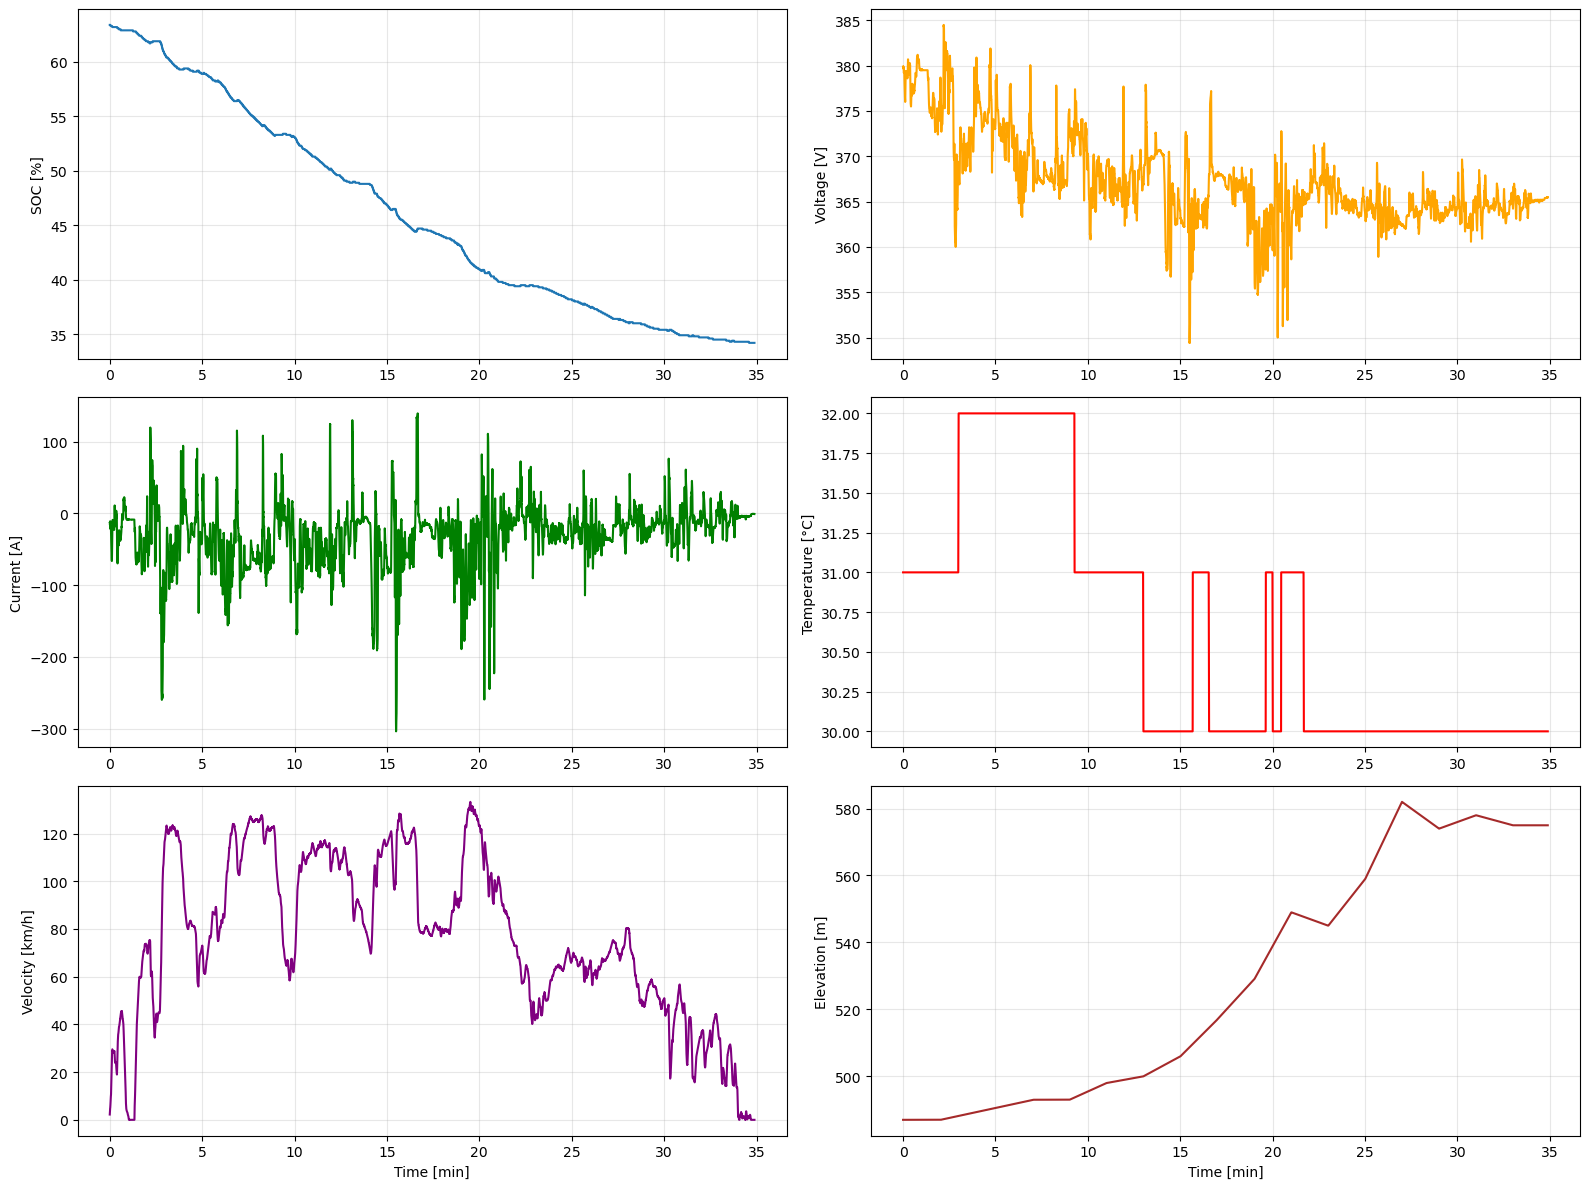

In [50]:
fig, axes = plt.subplots(3, 2, figsize=(16, 12))

axes[0,0].plot(df_summer['Time [s]']/60, df_summer[soc_col])
axes[0,0].set_ylabel('SOC [%]')
axes[0,0].grid(True, alpha=0.3)

axes[0,1].plot(df_summer['Time [s]']/60, df_summer[voltage_col], color='orange')
axes[0,1].set_ylabel('Voltage [V]')
axes[0,1].grid(True, alpha=0.3)

axes[1,0].plot(df_summer['Time [s]']/60, df_summer[current_col], color='green')
axes[1,0].set_ylabel('Current [A]')
axes[1,0].grid(True, alpha=0.3)

axes[1,1].plot(df_summer['Time [s]']/60, df_summer[temp_col], color='red')
axes[1,1].set_ylabel('Temperature [°C]')
axes[1,1].grid(True, alpha=0.3)

axes[2,0].plot(df_summer['Time [s]']/60, df_summer[velocity_col], color='purple')
axes[2,0].set_ylabel('Velocity [km/h]')
axes[2,0].set_xlabel('Time [min]')
axes[2,0].grid(True, alpha=0.3)

axes[2,1].plot(df_summer['Time [s]']/60, df_summer[elevation_col], color='brown')
axes[2,1].set_ylabel('Elevation [m]')
axes[2,1].set_xlabel('Time [min]')
axes[2,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [51]:
print(f"\nWinter Trip ({max_winter['Trip']}) - First 10 rows:")
display(df_winter.head(10))


Winter Trip (TripB14) - First 10 rows:


,Time [s],Velocity [km/h],Elevation [m],Throttle [%],Motor Torque [Nm],Longitudinal Acceleration [m/s^2],Regenerative Braking Signal,Battery Voltage [V],Battery Current [A],Battery Temperature [°C],max. Battery Temperature [°C],SoC [%],displayed SoC [%],min. SoC [%],max. SoC [%),Heating Power CAN [kW],Heating Power LIN [W],Requested Heating Power [W],AirCon Power [kW],Heater Signal,Heater Voltage [V],Heater Current [A],Ambient Temperature [°C],Ambient Temperature Sensor [°C],Coolant Temperature Heatercore [°C],Requested Coolant Temperature [°C],Coolant Temperature Inlet [°C],Coolant Volume Flow +500 [l/h],Heat Exchanger Temperature [°C],Cabin Temperature Sensor [°C],Temperature Coolant Heater Inlet [°C],Temperature Coolant Heater Outlet [°C],Temperature Heat Exchanger Outlet [°C],Temperature Defrost lateral left [°C],Temperature Defrost lateral right [°C],Temperature Defrost central [°C],Temperature Defrost central left [°C],Temperature Defrost central right [°C],Temperature Footweel Driver [°C],Temperature Footweel Co-Driver [°C],Temperature Feetvent Co-Driver [°C],Temperature Feetvent Driver [°C],Temperature Head Co-Driver [°C],Temperature Head Driver [°C],Temperature Vent right [°C],Temperature Vent central right [°C],Temperature Vent central left [°C],Temperature Vent right [°C]
0,0.0,0.0,500.0,0.0,0.0,-0.24,0.0,391.6,-1.10,3.0,4.0,85.5,100.0,8,88.5,0.0,0.0,0.0,0.0,1,394.0,0.0,3.0,3.54,3.0,85,3.0,-500.11,5.0,10.0,2.67,2.67,2.93,4.94,4.41,5.72,5.64,5.72,3.98,3.98,2.93,2.93,8.60,9.83,5.29,4.15,4.59,5.46
1,0.1,0.0,500.0,0.0,0.0,-0.27,0.0,391.6,-1.10,3.0,4.0,85.5,100.0,8,88.5,0.0,0.0,0.0,0.0,1,394.0,0.0,3.0,3.54,3.0,85,3.0,-500.11,5.0,10.0,2.67,2.67,2.93,4.94,4.41,5.72,5.64,5.72,3.98,3.98,2.93,2.93,8.60,9.83,5.29,4.15,4.59,5.46
2,0.2,0.0,500.0,0.0,0.0,-0.27,0.0,391.6,-1.10,3.0,4.0,85.5,100.0,8,88.5,0.0,0.0,0.0,0.0,1,394.0,0.0,3.0,3.54,3.0,85,3.0,-500.11,5.0,10.0,2.67,2.67,2.93,4.94,4.41,5.72,5.64,5.72,3.98,3.98,2.93,2.93,8.60,9.83,5.29,4.15,4.59,5.46
3,0.3,0.0,500.0,0.0,0.0,-0.25,0.0,391.6,-1.10,3.0,4.0,85.5,100.0,8,88.5,0.0,0.0,0.0,0.0,1,394.0,0.0,3.0,3.54,3.0,85,3.0,-500.11,5.0,10.0,2.67,2.67,2.93,4.94,4.41,5.72,5.64,5.72,3.98,3.98,2.93,2.93,8.59,9.84,5.29,4.15,4.59,5.47
4,0.4,0.0,500.0,0.0,0.0,-0.24,0.0,391.6,-1.10,3.0,4.0,85.5,100.0,8,88.5,0.0,0.0,0.0,0.0,1,394.0,0.0,3.0,3.54,3.0,85,3.0,-500.11,5.0,10.0,2.67,2.67,2.93,4.94,4.42,5.72,5.64,5.73,3.98,3.98,2.94,2.93,8.57,9.87,5.29,4.16,4.60,5.48
5,0.5,0.0,500.0,0.0,0.0,-0.23,0.0,391.6,-1.15,3.0,4.0,85.5,100.0,8,88.5,0.0,0.0,0.0,0.0,1,394.0,0.0,3.0,3.54,3.0,85,3.0,-500.11,5.0,10.0,2.67,2.66,2.93,4.94,4.43,5.72,5.64,5.74,3.98,3.98,2.95,2.93,8.56,9.89,5.30,4.17,4.60,5.48
6,0.6,0.0,500.0,0.0,0.0,-0.24,0.0,391.6,-1.20,3.0,4.0,85.5,100.0,8,88.5,0.0,0.0,0.0,0.0,1,394.0,0.0,3.0,3.54,3.0,85,3.0,-500.12,5.0,10.0,2.67,2.65,2.93,4.94,4.44,5.72,5.64,5.75,3.98,3.98,2.96,2.93,8.54,9.92,5.31,4.18,4.61,5.49
7,0.7,0.0,500.0,0.0,0.0,-0.24,0.0,391.6,-1.15,3.0,4.0,85.5,100.0,8,88.5,0.0,0.0,0.0,0.0,1,394.0,0.0,3.0,3.54,3.0,85,3.0,-500.12,5.0,10.0,2.67,2.64,2.93,4.94,4.45,5.72,5.64,5.76,3.98,3.98,2.96,2.93,8.52,9.95,5.32,4.19,4.62,5.50
8,0.8,0.0,500.0,0.0,0.0,-0.24,0.0,391.6,-1.10,3.0,4.0,85.5,100.0,8,88.5,0.0,0.0,0.0,0.0,1,394.0,0.0,3.0,3.54,3.0,85,3.0,-500.13,5.0,10.0,2.67,2.63,2.93,4.94,4.46,5.72,5.64,5.77,3.98,3.98,2.97,2.93,8.50,9.97,5.33,4.19,4.63,5.51
9,0.9,0.0,500.0,0.0,0.0,-0.24,0.0,391.6,-1.10,3.0,4.0,85.5,100.0,8,88.5,0.0,0.0,0.0,0.0,1,394.0,0.0,3.0,3.54,3.0,85,3.0,-500.14,5.0,10.0,2.67,2.63,2.93,4.94,4.47,5.72,5.64,5.77,3.98,3.98,2.98,2.93,8.49,10.00,5.34,4.20,4.64,5.52


In [52]:
soc_col_w = [col for col in df_winter.columns if 'SoC' in col and 'displayed' not in col][0]
voltage_col_w = [col for col in df_winter.columns if 'Battery Voltage' in col and 'min' not in col and 'max' not in col][0]
current_col_w = [col for col in df_winter.columns if 'Battery Current' in col and 'min' not in col and 'max' not in col][0]
temp_col_w = [col for col in df_winter.columns if 'Battery Temperature' in col and 'min' not in col and 'max' not in col][0]
velocity_col_w = [col for col in df_winter.columns if 'Velocity' in col and 'displayed' not in col and 'min' not in col and 'max' not in col][0]
elevation_col_w = [col for col in df_winter.columns if 'Elevation' in col][0]

print(f"\nSOC: {df_winter[soc_col_w].describe()}")
print(f"\nVoltage: {df_winter[voltage_col_w].describe()}")
print(f"\nCurrent: {df_winter[current_col_w].describe()}")
print(f"\nTemperature: {df_winter[temp_col_w].describe()}")
print(f"\nVelocity: {df_winter[velocity_col_w].describe()}")


SOC: count    38220.000000
mean        59.068196
std         16.926360
min          0.000000
25%         40.900000
50%         59.600000
75%         75.100000
max         85.500000
Name: SoC [%], dtype: float64

Voltage: count    38220.000000
mean       367.992133
std         10.791452
min        323.960000
25%        361.300000
50%        365.600000
75%        374.430000
max        391.600000
Name: Battery Voltage [V], dtype: float64

Current: count    38220.000000
mean       -29.604420
std         44.554905
min       -399.570000
25%        -45.100000
50%        -20.070000
75%         -5.990000
max        132.500000
Name: Battery Current [A], dtype: float64

Temperature: count    38220.000000
mean         8.775497
std          3.538689
min          3.000000
25%          5.000000
50%          9.000000
75%         13.000000
max         13.000000
Name: Battery Temperature [°C], dtype: float64

Velocity: count    38220.000000
mean        57.433053
std         33.978164
min          0.000

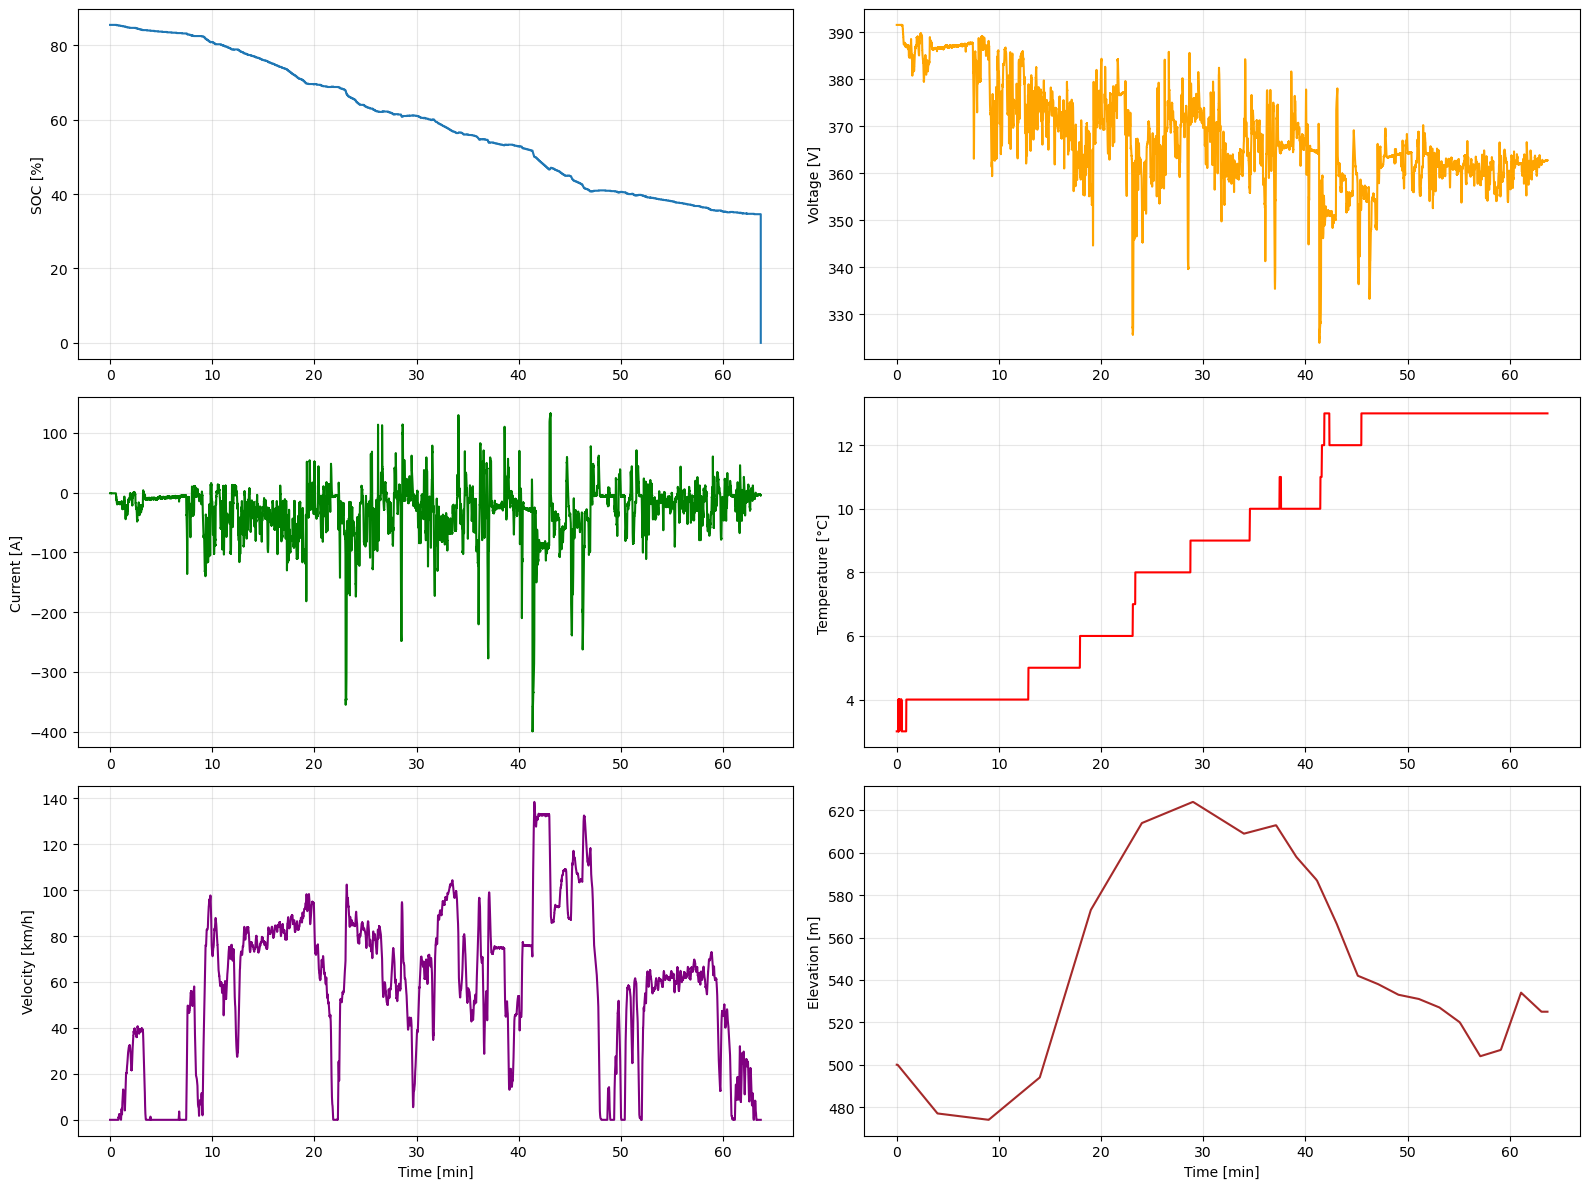

In [53]:
fig, axes = plt.subplots(3, 2, figsize=(16, 12))

axes[0,0].plot(df_winter['Time [s]']/60, df_winter[soc_col_w])
axes[0,0].set_ylabel('SOC [%]')
axes[0,0].grid(True, alpha=0.3)

axes[0,1].plot(df_winter['Time [s]']/60, df_winter[voltage_col_w], color='orange')
axes[0,1].set_ylabel('Voltage [V]')
axes[0,1].grid(True, alpha=0.3)

axes[1,0].plot(df_winter['Time [s]']/60, df_winter[current_col_w], color='green')
axes[1,0].set_ylabel('Current [A]')
axes[1,0].grid(True, alpha=0.3)

axes[1,1].plot(df_winter['Time [s]']/60, df_winter[temp_col_w], color='red')
axes[1,1].set_ylabel('Temperature [°C]')
axes[1,1].grid(True, alpha=0.3)

axes[2,0].plot(df_winter['Time [s]']/60, df_winter[velocity_col_w], color='purple')
axes[2,0].set_ylabel('Velocity [km/h]')
axes[2,0].set_xlabel('Time [min]')
axes[2,0].grid(True, alpha=0.3)

axes[2,1].plot(df_winter['Time [s]']/60, df_winter[elevation_col_w], color='brown')
axes[2,1].set_ylabel('Elevation [m]')
axes[2,1].set_xlabel('Time [min]')
axes[2,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()